In [ ]:
import pandas as pd
!pip install textblob
from textblob import TextBlob
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Amazon Externship/glassdoor_cleaned_text.csv')

In [ ]:
df

,review_id,rating_date,count_helpful,count_unhelpful,employee_length,employee_status,employee_type,flag_covid,flag_featured,flags_business_outlook,...,employee_job_title,advice_to_management,review_pros,review_cons,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities,review_pros_cleaned,review_cons_cleaned,summary_cleaned
0,1,2025-06-03T00:00:00.000Z,0,0,0.0,REGULAR,Current employee,False,False,NaN,...,Warehouse Fulfillment Associate,don’t micro manage,not interactive \ncan leave or take off whenev...,inhumane \ndraining physically &amp; mentally,0.0,0.0,0.0,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,amazon
1,2,2025-05-29T00:00:00.000Z,0,0,1.0,CONTRACT,"Current employee, less than 1 year",False,False,POSITIVE,...,Warehouse Associate,Remove all attitude manager from warehouse,good and easy work enviorment,"Sticks rules and completing targets any how, o...",5.0,3.0,5.0,good easy work enviorment,sticks rules completing targets otherwise get ...,good
2,3,2025-05-28T00:00:00.000Z,0,0,1.0,REGULAR,"Current employee, less than 1 year",False,False,POSITIVE,...,Warehouse Associate,NaN,"help to grow , good pay ,","limited opportunities for advancement,No clear...",5.0,5.0,5.0,help grow good pay,limited opportunities advancementno clear path...,good experience
3,4,2025-05-26T00:00:00.000Z,0,0,2.0,PART_TIME,Current employees,False,False,POSITIVE,...,Employee,NaN,Plenty of work\nMeet new people,Tough on the body\nLabor intensive,2.0,2.0,3.0,plenty work meet new people,tough body labor intensive,dhdh
4,5,2025-05-23T00:00:00.000Z,0,0,0.0,REGULAR,Current employee,False,False,NaN,...,Fulfillment Associate,NaN,Good Holiday pay \nAdditional benefits for per...,Not hiring permanent employees directly,0.0,0.0,0.0,good holiday pay additional benefits permanent...,hiring permanent employees directly,good pay rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,136,2023-03-26T00:00:00.000Z,0,0,NaN,REGULAR,Former employee,False,False,NEUTRAL,...,"Stower, picker, packer, waterspider, problem s...",NaN,-Your in control of your time (PTO)-(UPT) -Fle...,-Management (Department Varies) -Favoritism -L...,5.0,2.0,3.0,control time ptoupt flexibility good associate...,management department varies favoritism lack l...,cash cow job
135,137,2023-03-28T00:00:00.000Z,0,0,5.0,REGULAR,Former employee,False,False,POSITIVE,...,Order picker,More attention to the individual,If you do your job they leave you alone.,You are nothing but a number,3.0,2.0,2.0,job leave alone,nothing number,good attitude ok
136,138,2023-03-30T00:00:00.000Z,0,0,NaN,REGULAR,Former employee,False,False,NEUTRAL,...,Warehouse Associate,NaN,"Pay Long weekends (4 days on, 3 days off)",Long hours (10 hour days),NaN,NaN,NaN,pay long weekends 4 days 3 days,long hours 10 hour days,good pay long hours
137,139,2023-03-31T00:00:00.000Z,0,0,NaN,REGULAR,"Current employee, less than 1 year",False,False,NEUTRAL,...,"Fc associate i, direct",NaN,"4 days a week, great overtime pay rates","Long hours, night shift, routine work",5.0,4.0,4.0,4 days week great overtime pay rates,long hours night shift routine work,great place work


In [ ]:
df['sentiment_polarity'] = df['summary_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df['summary_cleaned'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [ ]:
def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_polarity'].apply(label_sentiment)

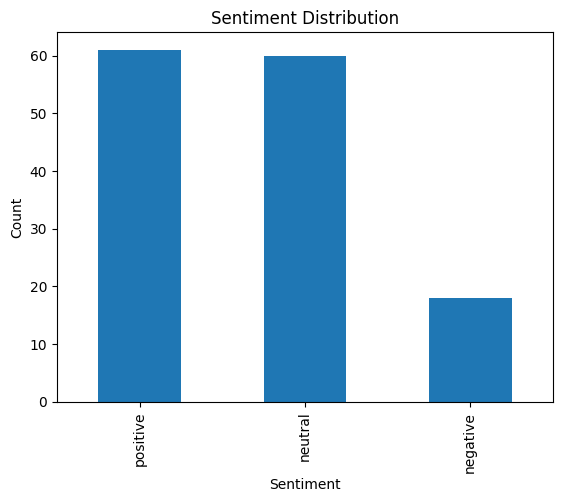

In [ ]:
df['sentiment_label'].value_counts().plot(kind='bar', title="Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


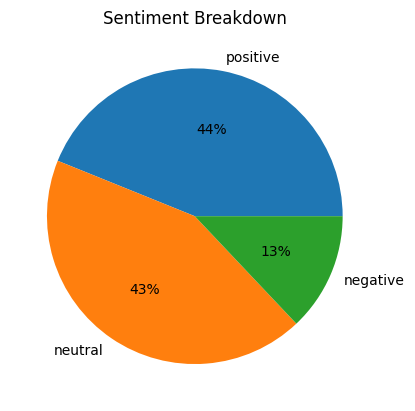

In [ ]:
df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [ ]:
df.to_csv('glassdoor_sentiment.csv', index=False)